# Redes Neuronales Convolucionales

En esta oportunidad buscaremos entrenar redes neuronales convolucionales para un conjunto de imágenes que corresponden a escenarios naturales del mundo, con seis diferentes clases:

- buildings: Para escenarios con edificios
- forest: Escenarios de bosques
- glacier: Glaciares
- mountain: Escenarios con montañas
- sea: Imágenes con mar
- street: Escenarios de ciudad

La base de datos se encuentra en cinco archivos serializados (pickle):

- cnn_train_X.npy: imágenes destinadas para entrenar los modelos
- cnn_train_y.npy: etiquetas asociadas a las imágenes de entrenamiento
- cnn_test_X.npy: imágenes para test
- cnn_test_y.npy: etiquetas correspondiente a las imágenes de test
- cnn_pred_X.npy conjunto de imágenes sin etiquetar destinadas a predicción

### Actividad 1

Importa correctamente los conjuntos de datos, desplegando la cantidad de registros de cada categoría para cada conjunto. Despliega ocho imágenes aleatorias del  conjunto de entrenamiento y codifica las etiquetas con OneHotEncoder para los conjuntos de entrenamiento y Test.

In [75]:
# Bibliotecas Comunes
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import mode

#Metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import classification_report

# Evaluacion de Modelos y Seleccion de Features
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV


import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, BatchNormalization
from keras.optimizers import Adam, SGD
from keras.initializers import glorot_normal, glorot_uniform
from keras.callbacks import EarlyStopping

In [2]:
X_train = np.load("/content/cnn_train_X.npy", allow_pickle=True)
X_train

array([[[[4.83218444e-01, 4.77753523e-01, 4.42892157e-01],
         [4.42853860e-01, 5.60868566e-01, 6.53841146e-01],
         [6.25566789e-01, 7.55468750e-01, 9.03530944e-01],
         ...,
         [2.65575214e-01, 3.94263174e-01, 5.33689491e-01],
         [2.57598039e-01, 3.87009804e-01, 5.24264706e-01],
         [2.53676471e-01, 3.83088235e-01, 5.20343137e-01]],

        [[1.84053309e-01, 1.82781863e-01, 1.28236060e-01],
         [8.19393382e-02, 6.15962010e-02, 6.57743566e-02],
         [4.32046569e-01, 5.09080116e-01, 5.74540441e-01],
         ...,
         [2.89215686e-01, 4.14705882e-01, 5.63725490e-01],
         [2.80514706e-01, 4.09926471e-01, 5.47181373e-01],
         [2.74509804e-01, 4.03921569e-01, 5.41176471e-01]],

        [[4.77443321e-02, 5.83946078e-02, 5.40709252e-02],
         [2.02094822e-01, 2.10462623e-01, 1.58528646e-01],
         [3.69324449e-01, 3.95921415e-01, 3.96683517e-01],
         ...,
         [3.14583333e-01, 4.43995098e-01, 5.81250000e-01],
         [

In [3]:
y_train = np.load("/content/cnn_train_y.npy", allow_pickle=True)
y_train

array(['forest', 'forest', 'forest', ..., 'sea', 'sea', 'sea'],
      dtype=object)

In [4]:
X_test = np.load("/content/cnn_test_X.npy", allow_pickle=True)
X_test

array([[[[0.38078278, 0.41730239, 0.16840533],
         [0.22517999, 0.21892999, 0.13574219],
         [0.65355392, 0.68818934, 0.4622932 ],
         ...,
         [0.16444547, 0.21016774, 0.10242417],
         [0.08369332, 0.12025506, 0.02462086],
         [0.39607843, 0.41625689, 0.27788756]],

        [[0.5574257 , 0.5981924 , 0.25910309],
         [0.42415748, 0.42807904, 0.23260953],
         [0.496358  , 0.54504442, 0.24555377],
         ...,
         [0.14867494, 0.18500306, 0.09480316],
         [0.19764093, 0.19861749, 0.09324066],
         [0.27339154, 0.30517004, 0.13017004]],

        [[0.61990656, 0.65412071, 0.34265089],
         [0.45060509, 0.44895833, 0.22327665],
         [0.58089767, 0.61821002, 0.34158624],
         ...,
         [0.22057292, 0.24809666, 0.06913297],
         [0.32774203, 0.37047718, 0.21074219],
         [0.18489583, 0.21339231, 0.10177313]],

        ...,

        [[0.19417509, 0.16690411, 0.17247243],
         [0.30849801, 0.31655178, 0.2384689 ]

In [5]:
y_test = np.load("/content/cnn_test_y.npy", allow_pickle=True)
y_test

array(['forest', 'forest', 'forest', ..., 'sea', 'sea', 'sea'],
      dtype=object)

In [6]:
X_pred = np.load("/content/cnn_pred_X.npy", allow_pickle=True)
X_pred

array([[[[4.34283088e-03, 2.08333333e-02, 3.05173866e-01],
         [3.25520833e-04, 2.38549326e-02, 3.15276501e-01],
         [0.00000000e+00, 3.02810968e-02, 3.23517923e-01],
         ...,
         [0.00000000e+00, 3.22303922e-02, 2.63602941e-01],
         [0.00000000e+00, 3.52941176e-02, 2.62339154e-01],
         [0.00000000e+00, 3.19852941e-02, 2.47671569e-01]],

        [[1.55101103e-03, 1.80568321e-02, 3.16996017e-01],
         [1.09030331e-02, 2.36443015e-02, 3.22675398e-01],
         [1.20098039e-02, 2.37745098e-02, 3.12323836e-01],
         ...,
         [0.00000000e+00, 3.05147059e-02, 2.73651961e-01],
         [0.00000000e+00, 3.13725490e-02, 2.62745098e-01],
         [3.25520833e-04, 3.56196385e-02, 2.59149050e-01]],

        [[2.21583946e-02, 2.77956495e-02, 2.56839767e-01],
         [1.72449449e-02, 3.23184743e-02, 2.63059130e-01],
         [3.43137255e-03, 2.37094056e-02, 3.25164675e-01],
         ...,
         [0.00000000e+00, 3.13725490e-02, 2.75367647e-01],
         [

In [7]:
def Show_Images(images_array: np.ndarray, labels_array: np.ndarray, index_images: np.ndarray, fig_size: tuple = (10,10)):
    """
    Muestra un conjunto de imágenes seleccionadas desde un array 4D (num_imágenes, alto, ancho, canales),
    junto con sus etiquetas.
    """
    # Seleccionar imágenes e inferir número
    selected_images = images_array[index_images]
    n = len(selected_images)

    # Calcular cuadrícula (lo más cuadrada posible)
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    # Crear figura
    fig, axes = plt.subplots(nrows, ncols, figsize=fig_size)

    # Asegurar que axes sea un array 1D
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    # Graficar imágenes
    for i in range(n):
        ax = axes[i]
        ax.imshow(selected_images[i])
        ax.axis('off')
        ax.set_title(f"Clase: {labels_array[index_images[i]]}")

    # Ocultar subplots vacíos (si sobran)
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


In [10]:
index_images = np.random.choice(X_train.shape[0], size=8, replace=False)
index_images

array([ 8724,  1865, 10129,  6900,  9565, 10484,  7821,  4133])

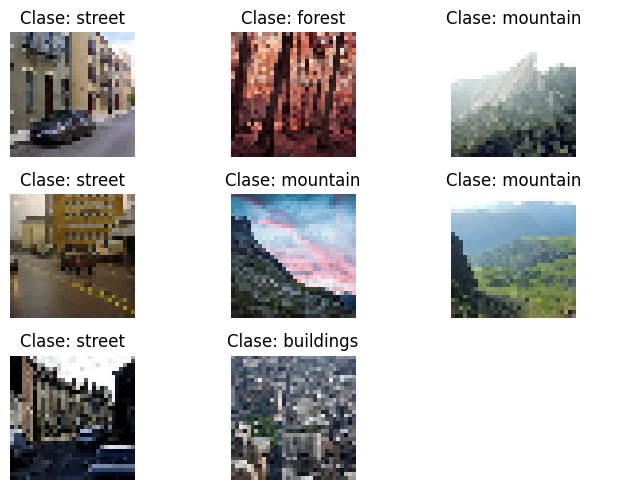

In [11]:
Show_Images(images_array=X_train, labels_array=y_train, index_images=index_images, fig_size= (7,5) )

In [12]:
# Crear y ajustar el encoder
encoder = OneHotEncoder(sparse_output=False)  # sparse_output=False devuelve un array normal
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded  = encoder.transform(y_test.reshape(-1, 1))

In [13]:
# Categorias de imagenes a identificar
encoder.categories_

[array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
       dtype=object)]

In [14]:
y_train_encoded

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]])

In [15]:
y_test_encoded

array([[0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]])

### Actividad 2

Implementa una red neuronal multicapa Fully Connected para clasificar las imágenes, las que deben contener un mínimo de cinco capas ocultas. Despliega las métricas (aplicadas al conjunto de test) que estimes conveniente para medir el rendimiento del modelo.

In [16]:
def Model_Sequential(X_train, y_train, X_test, y_test,
                    learning_rate:float,
                    epochs:int,
                    batch_size:int,
                    validation_split:float,
                    optimizer_name:str,
                    loss_name:str,
                    metrics:list,
                    n_features:int,
                    neurons_list:list,
                    activation_list:list,
                    kernel_initializer_list:list,
                    bias_initializer_list:list):

    # Creamos un modelo Secuencial
    model_sequential = Sequential()

    # Agregamos la capa de entrada
    model_sequential.add(Input(shape=(n_features,)))

    # Configurando capas
    for i, neurons in enumerate(neurons_list):
        model_sequential.add(Dense(neurons, activation=activation_list[i], kernel_initializer=kernel_initializer_list[i], bias_initializer=bias_initializer_list[i]))

    # Optimizador
    if optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Loss
    if loss_name == "mse":
        loss = tf.keras.losses.MeanSquaredError()
    elif loss_name == "mae":
        loss = tf.keras.losses.MeanAbsoluteError()
    elif loss_name == "categorical_crossentropy":
        loss = tf.keras.losses.CategoricalCrossentropy()
    elif loss_name == "binary_crossentropy":
        loss = tf.keras.losses.BinaryCrossentropy()
    else:
        loss = tf.keras.losses.MeanSquaredError()

    model_sequential.compile(
        optimizer=optimizer,
        loss=loss,  # función de pérdida para clasificación binaria
        metrics= metrics
    )

    # Entrenar el modelo
    history = model_sequential.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=validation_split, verbose=0)

    # Evaluar en test
    loss_test, metrics_test = model_sequential.evaluate(X_test, y_test)

    # Probabilidad de predicción
    y_proba_model_sequential = model_sequential.predict(X_test)

    # Diccionario de resultados de metricas y perdidas
    history_results = history.history

    return model_sequential, history, history_results, loss_test, metrics_test, y_proba_model_sequential

In [17]:
X_train.shape

(14034, 32, 32, 3)

In [18]:
y_train_encoded.shape[1]

6

In [19]:
# Antes de ingresar los datos de entrenamiento y test a la red neuronal, hay que cambiar las dimensiones a un array de una sola dimensión

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

In [20]:
model_01_config = {
    "learning_rate": 0.01,
    "epochs": 50,
    "batch_size": 32,
    "validation_split": 0.2,
    "optimizer_name": "adam",
    "loss_name": "categorical_crossentropy",
    "metrics": ["accuracy"],
    "n_features": X_train_flat.shape[1],
    "neurons_list": [6000, 1000, 500, 100, 20, y_train_encoded.shape[1]],
    "activation_list": ["relu", "relu", "relu", "relu", "relu", "softmax"],
    "kernel_initializer_list": ["he_normal", "he_normal", "he_normal", "he_normal", "he_normal", "glorot_uniform"],
    "bias_initializer_list": ["zeros", "zeros", "zeros", "zeros", "zeros", "zeros"]
}

In [21]:
# Modelo 1
model_sequential_01, history_01, history_results_01, loss_test_01, metrics_test_01, y_proba_model_sequential_01 = Model_Sequential(
                    X_train_flat, y_train_encoded, X_test_flat, y_test_encoded,
                    learning_rate = model_01_config["learning_rate"],
                    epochs = model_01_config["epochs"],
                    batch_size = model_01_config["batch_size"],
                    validation_split = model_01_config["validation_split"],
                    optimizer_name = model_01_config["optimizer_name"],
                    loss_name = model_01_config["loss_name"],
                    metrics = model_01_config["metrics"],
                    n_features = model_01_config["n_features"],
                    neurons_list = model_01_config["neurons_list"],
                    activation_list = model_01_config["activation_list"],
                    kernel_initializer_list = model_01_config["kernel_initializer_list"],
                    bias_initializer_list=model_01_config["bias_initializer_list"])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1737 - loss: 1.8589
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
# Guardando modelo
model_sequential_01.save('model_sequential_01.keras')

In [22]:
y_proba_model_sequential_01

array([[1.9066936e-01, 1.9442013e-01, 2.1774046e-01, 1.8266901e-01,
        3.3288035e-07, 2.1450081e-01],
       [1.9066936e-01, 1.9442013e-01, 2.1774046e-01, 1.8266901e-01,
        3.3288035e-07, 2.1450081e-01],
       [1.9066936e-01, 1.9442013e-01, 2.1774046e-01, 1.8266901e-01,
        3.3288035e-07, 2.1450081e-01],
       ...,
       [1.9066936e-01, 1.9442013e-01, 2.1774046e-01, 1.8266901e-01,
        3.3288035e-07, 2.1450081e-01],
       [1.9066936e-01, 1.9442013e-01, 2.1774046e-01, 1.8266901e-01,
        3.3288035e-07, 2.1450081e-01],
       [1.9066936e-01, 1.9442013e-01, 2.1774046e-01, 1.8266901e-01,
        3.3288035e-07, 2.1450081e-01]], dtype=float32)

In [23]:
# Convertir a clases
y_pred_model_sequential_01_classes = np.argmax(y_proba_model_sequential_01, axis=1)
y_test_model_sequential_01_classes = np.argmax(y_test_encoded, axis=1)

In [24]:
y_pred_model_sequential_01_classes

array([2, 2, 2, ..., 2, 2, 2])

In [25]:
y_test_model_sequential_01_classes

array([1, 1, 1, ..., 4, 4, 4])

In [26]:
# Métricas
print("Accuracy:", accuracy_score(y_test_model_sequential_01_classes, y_pred_model_sequential_01_classes))
print("\nMatriz de confusión:\n", confusion_matrix(y_test_model_sequential_01_classes, y_pred_model_sequential_01_classes))
print("\nReporte de clasificación:\n", classification_report(y_test_model_sequential_01_classes, y_pred_model_sequential_01_classes))

auc_macro = roc_auc_score(y_test_encoded, y_proba_model_sequential_01, multi_class='ovr', average='macro')
print("\nAUC macro:", auc_macro)

Accuracy: 0.18433333333333332

Matriz de confusión:
 [[  0   0 437   0   0   0]
 [  0   0 474   0   0   0]
 [  0   0 553   0   0   0]
 [  0   0 525   0   0   0]
 [  0   0 510   0   0   0]
 [  0   0 501   0   0   0]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       437
           1       0.00      0.00      0.00       474
           2       0.18      1.00      0.31       553
           3       0.00      0.00      0.00       525
           4       0.00      0.00      0.00       510
           5       0.00      0.00      0.00       501

    accuracy                           0.18      3000
   macro avg       0.03      0.17      0.05      3000
weighted avg       0.03      0.18      0.06      3000


AUC macro: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
# La Red no fue capaz de predecir y clasificar correctamente las imagenes, se presentan malas metricas

### Actividad 3

Desarrolla una red neuronal Convolucional usando tres o más capas convolucionales y dos o más capas densas, de manera que la cantidad de parámetros a estimar se encuentre en el intervalo [3MM, 8MM], con 25 épocas. Muestra la curva de la pérdida para cada época y la curva de la métrica accuracy (conjunto test).

In [28]:
class Model_Convolutional_Sequential_Multiple_Classifier:

    def __init__(self,
                optimizer_name:str,
                learning_rate:float,
                loss_name:str,
                metrics:list[str],
                conv_inputshape:tuple,
                conv_layersnumber:int,
                conv_filters_list:list[int],
                conv_kernel_list:list[tuple],
                conv_activation_list:list[str],
                conv_padding_list:list[str],
                conv_batchnormalization_list:list[bool],
                conv_dropout_list:list[float|None],
                conv_poolingtype_list:list[str|None],
                conv_poolsize_list:list[tuple],
                dense_neurons_list:list[int],
                dense_activation_list:list[str],
                dense_kernelinitializer_list:list[str],
                dense_biasinitializer_list:list[str],
                dense_dropout_list:list[float|None],
                 ):

        self.optimizer_name = optimizer_name
        self.learning_rate = learning_rate
        self.loss_name = loss_name
        self.metrics = metrics
        self.conv_inputshape = conv_inputshape
        self.conv_layersnumber = conv_layersnumber
        self.conv_filters_list = conv_filters_list
        self.conv_kernel_list = conv_kernel_list
        self.conv_activation_list = conv_activation_list
        self.conv_padding_list = conv_padding_list
        self.conv_batchnormalization_list = conv_batchnormalization_list
        self.conv_dropout_list = conv_dropout_list
        self.conv_poolingtype_list = conv_poolingtype_list
        self.conv_poolsize_list = conv_poolsize_list
        self.dense_neurons_list = dense_neurons_list
        self.dense_activation_list = dense_activation_list
        self.dense_kernelinitializer_list = dense_kernelinitializer_list
        self.dense_biasinitializer_list = dense_biasinitializer_list
        self.dense_dropout_list = dense_dropout_list

        # Sequential Model
        self.model = Sequential()

        # Building Model
        self.__model_contructor()

    # Model constructor private method
    def __model_contructor(self):

        # Optimizer
        if self.optimizer_name == "adam":
            optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        else:
            optimizer = tf.keras.optimizers.SGD(learning_rate=self.learning_rate)

        # Loss
        if self.loss_name == "mse":
            loss = tf.keras.losses.MeanSquaredError()
        elif self.loss_name == "mae":
            loss = tf.keras.losses.MeanAbsoluteError()
        elif self.loss_name == "categorical_crossentropy":
            loss = tf.keras.losses.CategoricalCrossentropy()
        elif self.loss_name == "binary_crossentropy":
            loss = tf.keras.losses.BinaryCrossentropy()
        else:
            loss = tf.keras.losses.MeanSquaredError()

        # Input Layer
        self.model.add(Input(shape=self.conv_inputshape))

        # Convolutional Layers
        for i in range(self.conv_layersnumber):

            # Convolutional Layer
            self.model.add(Conv2D(self.conv_filters_list[i],
                                self.conv_kernel_list[i],
                                activation=self.conv_activation_list[i],
                                padding=self.conv_padding_list[i]))

            # BatchNormalization
            if self.conv_batchnormalization_list[i] == True:
                self.model.add(BatchNormalization())

            # Pooling
            if self.conv_poolingtype_list[i] == "max" and isinstance(self.conv_poolsize_list[i], tuple):
                self.model.add(MaxPooling2D(pool_size=self.conv_poolsize_list[i]))
            elif self.conv_poolingtype_list[i] == "average" and isinstance(self.conv_poolsize_list[i], tuple):
                self.model.add(AveragePooling2D(pool_size=self.conv_poolsize_list[i]))

            # Dropout
            if isinstance(self.conv_dropout_list[i], float):
                self.model.add(Dropout(rate=self.conv_dropout_list[i]))

        # Flatten
        self.model.add(Flatten())

        # Dense layers number
        n_dense_layers = len(self.dense_neurons_list)

        # Dense Layers
        for i in range(n_dense_layers):

            # Dense Layer
            self.model.add(Dense(units=self.dense_neurons_list[i],
                                activation=self.dense_activation_list[i],
                                kernel_initializer=self.dense_kernelinitializer_list[i],
                                bias_initializer=self.dense_biasinitializer_list[i]))

            # Dropout
            if isinstance(self.dense_dropout_list[i], float):
                self.model.add(Dropout(rate=self.dense_dropout_list[i]))

        self.model.compile(optimizer=optimizer, loss=loss, metrics=self.metrics)
        self.model.summary()

    # Return model method
    def return_model(self):
        return self.model

    # Fit and evaluate method
    def fit_evaluate(self, X_train, y_train, X_test, y_test, epochs:int, batch_size:int, early_stopping:bool=True):

        # Callbacks
        if early_stopping == True:
            callbacks = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
        else:
            callbacks = []

        # Fit
        self.history = self.model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=epochs, batch_size=batch_size, verbose=0, callbacks=callbacks)
        self.history_results = self.history.history

        # Evaluate
        loss_test, metrics_test = self.model.evaluate(X_test, y_test)

        return self.model, self.history, self.history_results, loss_test, metrics_test

    # Show evolution results
    def show_evolution_loss(self):

        # Show Loss
        plt.plot(self.history_results['loss'], label='train_loss')
        plt.plot(self.history_results['val_loss'], label='val_loss')
        plt.legend()
        plt.title("Lost by epochs")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.show()

    # Show evolution results
    def show_evolution_metric(self, fig_size:tuple):

        n = len(self.metrics)

        # Calculate grid (as square as possible)
        ncols = math.ceil(math.sqrt(n))
        nrows = math.ceil(n / ncols)

        # Create figure
        fig, axes = plt.subplots(nrows, ncols, figsize=fig_size)

        # Ensure that axes is a 1D array
        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        else:
            axes = np.array([axes])

        # Show metrics
        for i, metric in enumerate(self.metrics):
            ax = axes[i]

            if metric in self.history_results:

                ax.plot(self.history_results[metric], label=f"train_{metric}")
                ax.plot(self.history_results[f"val_{metric}"], label=f"val_{metric}")
                ax.set_title(f"{metric} by epoch")
                ax.set_xlabel("epochs")
                ax.set_ylabel(metric)
                ax.legend()
                ax.grid(True)

        # Delete empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    # Predict method
    def predict(self, X_pred):

        # Prediction probability
        y_proba_pred = self.model.predict(X_pred)

        # Prediction class
        y_class_pred = np.argmax(y_proba_pred, axis=1)

        return y_proba_pred, y_class_pred



In [29]:
# Model configuration data
model_02_config = {
    "optimizer_name": "adam",
    "learning_rate": 0.01,
    "loss_name": "categorical_crossentropy",
    "metrics": ["accuracy"],
    "conv_inputshape": (32,32,3),
    "conv_layersnumber": 3,
    "conv_filters_list": [64,128,256],
    "conv_kernel_list": [(3,3), (3,3), (3,3)],
    "conv_activation_list": ["relu", "relu", "relu"],
    "conv_padding_list": ["same", "same", "same"],
    "conv_batchnormalization_list": [True, True,True],
    "conv_dropout_list": [None, None, None],
    "conv_poolingtype_list": ["max","max", "max"],
    "conv_poolsize_list": [(2,2),(2,2), (2,2)],
    "dense_neurons_list": [2048, 1024, 128, y_train_encoded.shape[1]],
    "dense_activation_list": ["relu", "relu", "relu", "softmax"],
    "dense_kernelinitializer_list": ["he_normal", "he_normal", "he_normal", "glorot_uniform"],
    "dense_biasinitializer_list":["zeros", "zeros", "zeros", "zeros"],
    "dense_dropout_list": [0.3, 0.2, 0.1, None],
    "epochs": 25,
    "batch_size": 32,
    "early_stopping": False
}

In [30]:
Model_Object_02 = Model_Convolutional_Sequential_Multiple_Classifier(
    optimizer_name=model_02_config["optimizer_name"],
    learning_rate=model_02_config["learning_rate"],
    loss_name=model_02_config["loss_name"],
    metrics=model_02_config["metrics"],
    conv_inputshape=model_02_config["conv_inputshape"],
    conv_layersnumber=model_02_config["conv_layersnumber"],
    conv_filters_list=model_02_config["conv_filters_list"],
    conv_kernel_list=model_02_config["conv_kernel_list"],
    conv_activation_list=model_02_config["conv_activation_list"],
    conv_padding_list=model_02_config["conv_padding_list"],
    conv_batchnormalization_list=model_02_config["conv_batchnormalization_list"],
    conv_dropout_list=model_02_config["conv_dropout_list"],
    conv_poolingtype_list=model_02_config["conv_poolingtype_list"],
    conv_poolsize_list=model_02_config["conv_poolsize_list"],
    dense_neurons_list=model_02_config["dense_neurons_list"],
    dense_activation_list=model_02_config["dense_activation_list"],
    dense_kernelinitializer_list=model_02_config["dense_kernelinitializer_list"],
    dense_biasinitializer_list=model_02_config["dense_biasinitializer_list"],
    dense_dropout_list=model_02_config["dense_dropout_list"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,993,414 (41.94 MB)

 Trainable params: 10,992,518 (41.93 MB)

 Non-trainable params: 896 (3.50 KB)

In [31]:
print("Shapes:")
print("X_train:", X_train.shape)
print("y_train_encoded:", y_train_encoded.shape)
print("X_test:", X_test.shape)
print("y_test_encoded:", y_test_encoded.shape)
print("X_pred:", X_pred.shape)

Shapes:
X_train: (14034, 32, 32, 3)
y_train_encoded: (14034, 6)
X_test: (3000, 32, 32, 3)
y_test_encoded: (3000, 6)
X_pred: (7301, 32, 32, 3)


In [32]:
model_02, history_02, history_results_02, loss_test_02, metrics_test_02 = Model_Object_02.fit_evaluate(X_train=X_train,
                                                                                                       y_train=y_train_encoded,
                                                                                                       X_test=X_test,
                                                                                                       y_test=y_test_encoded,
                                                                                                       epochs=model_02_config["epochs"],
                                                                                                       batch_size=model_02_config["batch_size"],
                                                                                                       early_stopping=model_02_config["early_stopping"]
                                                                                                       )

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1737 - loss: 1.8092


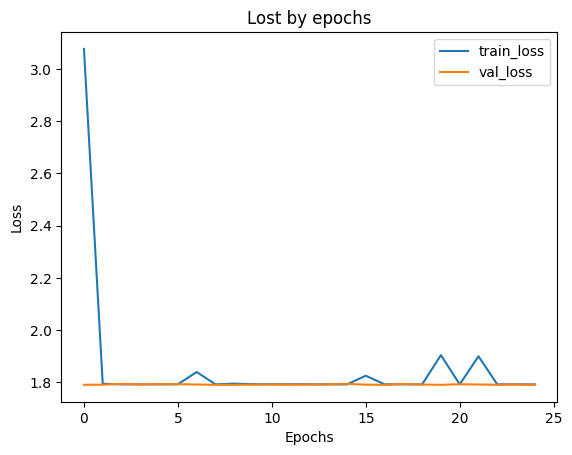

In [33]:
Model_Object_02.show_evolution_loss()

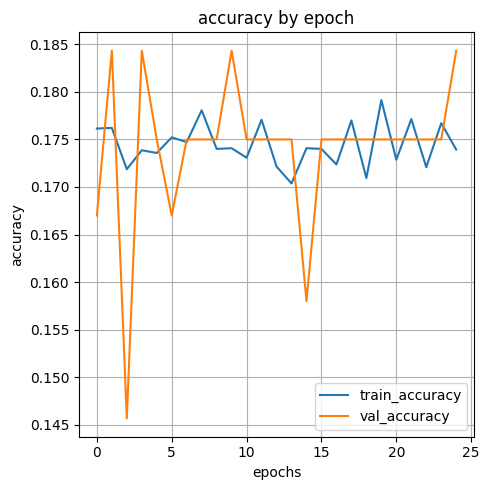

In [34]:
Model_Object_02.show_evolution_metric((5,5))

### Actividad 4

Implementa una red neuronal Convolucional que mejore la capacidad de generalización alcanzada en el modelo anterior. Para esto usa 16 o más capas (entre convolucionales y densas) y mide su rendimiento.

Luego, con el modelo entrenado, aplícalo sobre el conjunto de predicción, mide su rendimiento y compáralo con el rendimiento calculado en el modelo anterior. ¿Para qué etiqueta el modelo se equivoca más? Muestra en forma aleatoria ocho imágenes con la etiqueta de predicción otorgada por el modelo.

In [35]:
# Model configuration data
model_03_config = {
    "optimizer_name": "adam",
    "learning_rate": 0.0005,
    "loss_name": "categorical_crossentropy",
    "metrics": ["accuracy"],
    "conv_inputshape": (32,32,3),
    "conv_layersnumber": 8,
    "conv_filters_list": [64,64,64,128,128,128,256,256],
    "conv_kernel_list": [(3,3), (3,3), (3,3), (3,3), (3,3), (3,3), (3,3), (3,3)],
    "conv_activation_list": ["relu", "relu", "relu", "relu", "relu", "relu", "relu", "relu"],
    "conv_padding_list": ["same", "same", "same", "same", "same", "same", "same", "same"],
    "conv_batchnormalization_list": [True, True, True, True, True, True, True, True],
    "conv_dropout_list": [None, None, None, None, None, 0.3, None, 0.3],
    "conv_poolingtype_list": [None, None, None, None, None, "max", None, "max"],
    "conv_poolsize_list": [None, None, None, None, None, (2,2), None, (2,2)],
    "dense_neurons_list": [4096, 2048, 1024, 512, 128, y_train_encoded.shape[1]],
    "dense_activation_list": ["relu", "relu", "relu", "relu", "relu", "softmax"],
    "dense_kernelinitializer_list": ["he_normal", "he_normal", "he_normal", "he_normal", "he_normal", "glorot_uniform"],
    "dense_biasinitializer_list":["zeros", "zeros", "zeros", "zeros", "zeros", "zeros"],
    "dense_dropout_list": [0.3, 0.3, 0.2, 0.1, 0.1, None],
    "epochs": 50,
    "batch_size": 32,
    "early_stopping": False
}

In [36]:
Model_Object_03 = Model_Convolutional_Sequential_Multiple_Classifier(
    optimizer_name=model_03_config["optimizer_name"],
    learning_rate=model_03_config["learning_rate"],
    loss_name=model_03_config["loss_name"],
    metrics=model_03_config["metrics"],
    conv_inputshape=model_03_config["conv_inputshape"],
    conv_layersnumber=model_03_config["conv_layersnumber"],
    conv_filters_list=model_03_config["conv_filters_list"],
    conv_kernel_list=model_03_config["conv_kernel_list"],
    conv_activation_list=model_03_config["conv_activation_list"],
    conv_padding_list=model_03_config["conv_padding_list"],
    conv_batchnormalization_list=model_03_config["conv_batchnormalization_list"],
    conv_dropout_list=model_03_config["conv_dropout_list"],
    conv_poolingtype_list=model_03_config["conv_poolingtype_list"],
    conv_poolsize_list=model_03_config["conv_poolsize_list"],
    dense_neurons_list=model_03_config["dense_neurons_list"],
    dense_activation_list=model_03_config["dense_activation_list"],
    dense_kernelinitializer_list=model_03_config["dense_kernelinitializer_list"],
    dense_biasinitializer_list=model_03_config["dense_biasinitializer_list"],
    dense_dropout_list=model_03_config["dense_dropout_list"]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             

 Total params: 79,527,302 (303.37 MB)

 Trainable params: 79,525,126 (303.36 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [37]:
model_03, history_03, history_results_03, loss_test_03, metrics_test_03 = Model_Object_03.fit_evaluate(X_train=X_train,
                                                                                                       y_train=y_train_encoded,
                                                                                                       X_test=X_test,
                                                                                                       y_test=y_test_encoded,
                                                                                                       epochs=model_03_config["epochs"],
                                                                                                       batch_size=model_03_config["batch_size"],
                                                                                                       early_stopping=model_03_config["early_stopping"]
                                                                                                       )

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8352 - loss: 1.0240


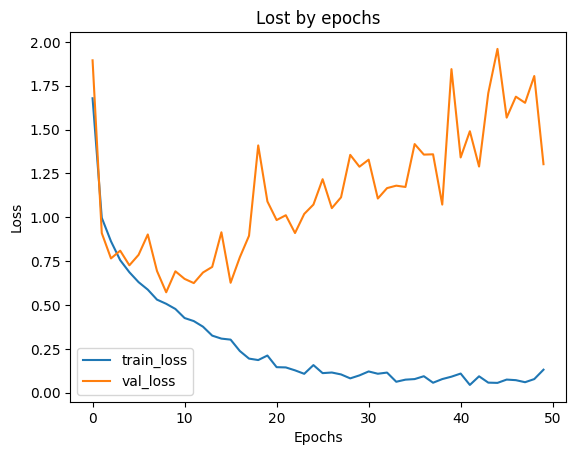

In [38]:
Model_Object_03.show_evolution_loss()

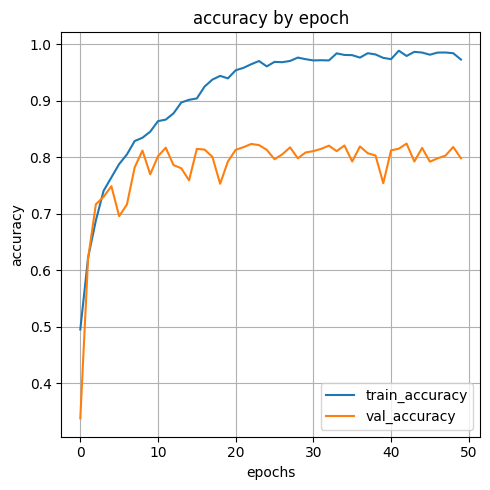

In [39]:
Model_Object_03.show_evolution_metric((5,5))

In [68]:
# Predict X_test
y_proba_test_pred_03, y_class_test_pred_03 = Model_Object_03.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [69]:
y_class_test_pred_03

array([1, 1, 1, ..., 4, 4, 4])

In [70]:
y_class_test_true = np.argmax(y_test_encoded, axis=1)
y_class_test_true

array([1, 1, 1, ..., 4, 4, 4])

In [41]:
# Predict
y_proba_pred_03, y_class_pred_03 = Model_Object_03.predict(X_pred)

229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


In [42]:
y_proba_pred_03

array([[2.2608812e-01, 4.9400769e-02, 1.4637250e-01, 1.1278256e-01,
        3.5731986e-01, 1.0803619e-01],
       [5.1317148e-13, 2.2270120e-12, 4.2388734e-08, 1.0000000e+00,
        5.7781353e-09, 1.7918603e-14],
       [4.3920494e-09, 9.7391850e-10, 9.9886698e-01, 1.1054577e-03,
        2.7470385e-05, 5.8039582e-08],
       ...,
       [5.8443210e-04, 2.9165966e-03, 6.1523169e-02, 9.2310065e-01,
        1.0686527e-02, 1.1886851e-03],
       [1.9778028e-10, 7.4796967e-14, 1.0395179e-23, 4.0118163e-30,
        0.0000000e+00, 1.0000000e+00],
       [3.6151057e-05, 2.6838426e-05, 9.6428120e-01, 3.2910284e-02,
        2.5382938e-03, 2.0722709e-04]], dtype=float32)

In [43]:
y_class_pred_03

array([4, 3, 2, ..., 3, 5, 2])

In [210]:
# Comparamos las metricas accuracy de ambos modelos: modelo_02 y modelo_03. Se pueden observar mejores métricas en el modelo_03
# Se entiende que añadiendo más filtros, mayor complejidad y mayores parametros, se logra una mejor modelación

In [211]:
# No se dispone de los valores reales del conjuto de predicción. Es decir, no poseemos y_pred_true
# Por lo tanto, haremos algunos examenes estadisticos y visuales para ver cómo se comporta con los datos predichos

In [44]:
# Confianza Media
confianza_media = np.mean(np.max(y_proba_pred_03, axis=1))
print(f"Confianza promedio de predicción del modelo_03: {confianza_media:.2f}")

Confianza promedio de predicción del modelo_03: 0.94


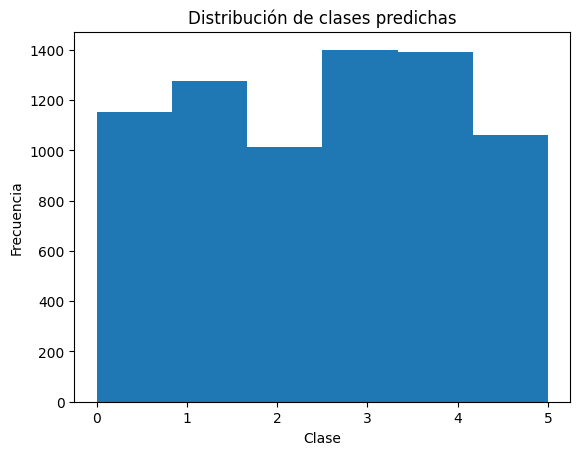

In [81]:
# Distribución de clases predichas

plt.hist(y_class_pred_03, bins=len(np.unique(y_class_pred_03)))
plt.title("Distribución de clases predichas")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

In [80]:
# Contar cantidad de predicciones por clase

class_names = encoder.categories_[0]
y_labels_pred_03 = [class_names[i] for i in y_class_pred_03]

unique, counts = np.unique(y_class_pred_03, return_counts=True)

# Crear DataFrame con nombre de la clase y cantidad
df_pred_counts = pd.DataFrame({
    'clase_id': unique,
    'clase_nombre': [class_names[i] for i in unique],
    'cantidad_predicciones': counts
})

df_pred_counts

,clase_id,clase_nombre,cantidad_predicciones
0,0,buildings,1155
1,1,forest,1277
2,2,glacier,1015
3,3,mountain,1401
4,4,sea,1393
5,5,street,1060


In [251]:
# Visualmente y según las distribuciones de frecuencia, la categoría más predicha es "mountain"

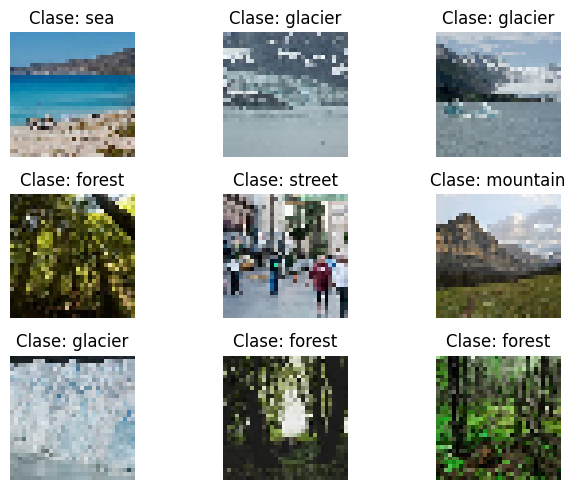

In [53]:
# Haremos una comprobacion visual de imagenes random versus sus etiquetas

index_img_pred_random = np.random.choice(X_pred.shape[0], size=9, replace=False)
Show_Images(images_array=X_pred, labels_array=y_labels_pred_03, index_images=index_img_pred_random, fig_size= (7,5) )


In [ ]:
# Se puede apreciar una buena clasificación en las imagenes de muestra

In [82]:
# Evaluando aciertos y errores por clase en base a X_test e y_test
cmatrix = confusion_matrix(y_class_test_true, y_class_test_pred_03)

# Total de muestras por clase
total_por_clase = cmatrix.sum(axis=1)

# Aciertos por clase (diagonal principal)
aciertos_por_clase = np.diag(cmatrix)

# Errores por clase
errores_por_clase = total_por_clase - aciertos_por_clase

# Porcentaje de error
error_rate = errores_por_clase / total_por_clase

# DataFrame resumen
df_error = pd.DataFrame({
    'Clase': class_names,
    'Total': total_por_clase,
    'Aciertos': aciertos_por_clase,
    'Errores': errores_por_clase,
    'Error (%)': np.round(error_rate * 100, 2)
}).sort_values(by='Error (%)', ascending=False).reset_index(drop=True)

print(df_error)

       Clase  Total  Aciertos  Errores  Error (%)
0    glacier    553       357      196      35.44
1     street    501       374      127      25.35
2  buildings    437       334      103      23.57
3   mountain    525       428       97      18.48
4        sea    510       442       68      13.33
5     forest    474       459       15       3.16
